In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Read one TXT file and convert it into DataFrame

In [6]:
df_example = pd.read_csv(r'C:\Users\adayc\Desktop\code\Drug\DA_data\CGM_id_only\DA001.txt', sep='\t')
df_example.head()

,,,# DA001
ID,时间,记录类型,葡萄糖历史记录（mmol/L）
258287,2019/10/28 10:21,0,4.3
258288,2019/10/28 10:36,0,4.5
258289,2019/10/28 10:51,0,5.1
258290,2019/10/28 11:06,0,5.0


Read all files

In [7]:
cgm_data_path = r'C:\Users\adayc\Desktop\code\Drug\DA_data\CGM_id_only'
txt_files = [f for f in os.listdir(cgm_data_path) if f.endswith('.txt')]

In [8]:
patients_data = {}
for file in txt_files:
    file_path = os.path.join(cgm_data_path, file)
    df = pd.read_csv(file_path, sep='\t', skiprows=1)
    # change column names
    df = df.rename(columns={
    "ID": "data_ID",
    "时间": "Timestamp",
    "记录类型": "Record_Type",
    "葡萄糖历史记录（mmol/L）": "Glucose_History"
    })

    # set patient_id
    patient_id = file.split('.')[0]  
    patients_data[patient_id] = df

In [9]:
patients_data['DA123']

,data_ID,Timestamp,Record_Type,Glucose_History
0,344845,2019/11/08 09:53,0,7.6
1,344846,2019/11/08 10:08,0,7.1
2,344847,2019/11/08 10:23,0,7.0
3,344848,2019/11/08 10:38,0,7.4
4,344849,2019/11/08 10:53,0,7.4
...,...,...,...,...
403,345248,2019/11/12 14:38,0,5.7
404,345249,2019/11/12 14:53,0,5.1
405,345250,2019/11/12 15:08,0,5.1
406,345251,2019/11/12 15:23,0,5.3


14天CGM数据，共有200名测试者

0. 检查日期时间分布

数据取自2019年10月28日至2019年11月29日

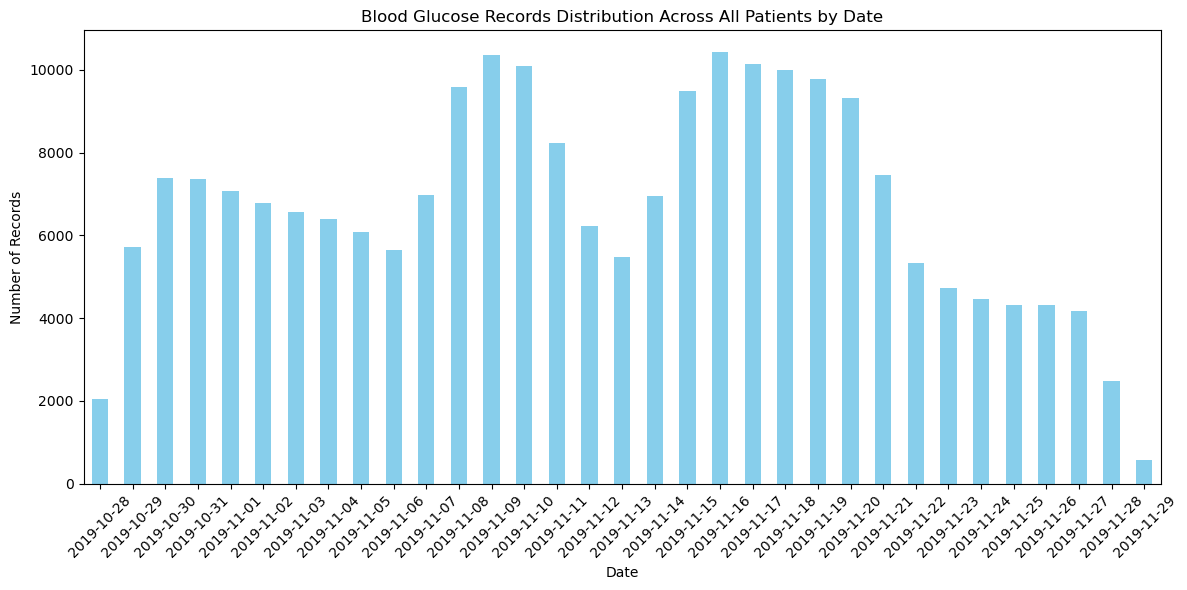

In [10]:
all_dates = []

for patient_id, patient_data in patients_data.items():
    patient_data['Timestamp'] = pd.to_datetime(patient_data['Timestamp'])
    patient_dates = patient_data['Timestamp'].dt.date
    all_dates.extend(patient_dates)

dates_df = pd.DataFrame(all_dates, columns=['Date'])

date_counts = dates_df['Date'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
date_counts.plot(kind='bar', color='skyblue')

plt.title('Blood Glucose Records Distribution Across All Patients by Date')
plt.xlabel('Date')
plt.ylabel('Number of Records')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

1. 个别测试者14天的血糖变化

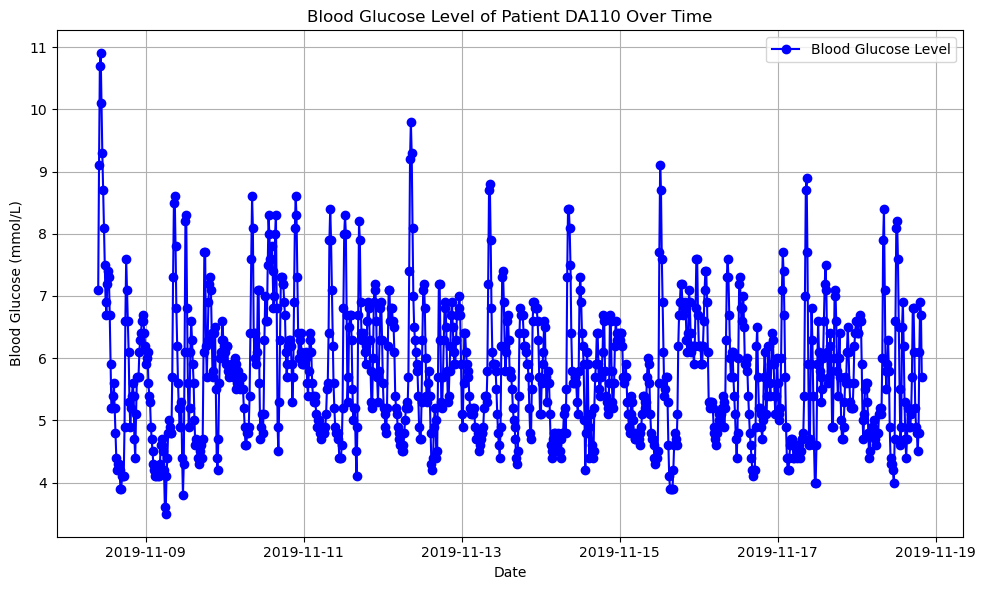

In [11]:
# Change DA_ID to see different patient data
DA_ID = 'DA110'
patient = patients_data[DA_ID]

patient['Timestamp'] = pd.to_datetime(patient['Timestamp'])
plt.figure(figsize=(10, 6)) 
plt.plot(patient['Timestamp'], patient['Glucose_History'], label='Blood Glucose Level', color='blue', marker='o')

plt.title(f'Blood Glucose Level of Patient {DA_ID} Over Time')
plt.xlabel('Date')
plt.ylabel('Blood Glucose (mmol/L)')

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

2. 个别测试者某一天的血糖变化

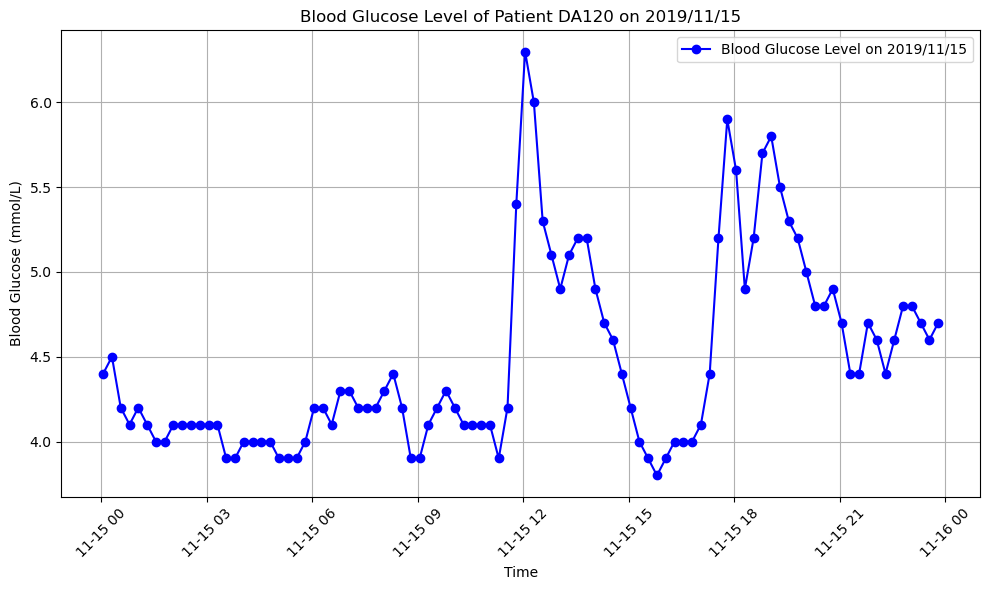

In [12]:
DA_ID = 'DA120'
patient = patients_data[DA_ID]
specific_date = '2019/11/15'  # 2019/10/28 - 2019/11/29, try other dates if not exist

patient['Timestamp'] = pd.to_datetime(patient['Timestamp'])

# Filter data for the specific date
filtered_data = patient[patient['Timestamp'].dt.date == pd.to_datetime(specific_date).date()]

plt.figure(figsize=(10, 6)) 
plt.plot(filtered_data['Timestamp'], filtered_data['Glucose_History'], label=f'Blood Glucose Level on {specific_date}', color='blue', marker='o')
plt.title(f'Blood Glucose Level of Patient {DA_ID} on {specific_date}')
plt.xlabel('Time')
plt.ylabel('Blood Glucose (mmol/L)')

plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

3. 同一时间段内所有测试者的血糖值分布

C:\Users\adayc\AppData\Local\Temp\ipykernel_22628\1489744831.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hour', y='Glucose_History', data=df_all, palette='Set2')


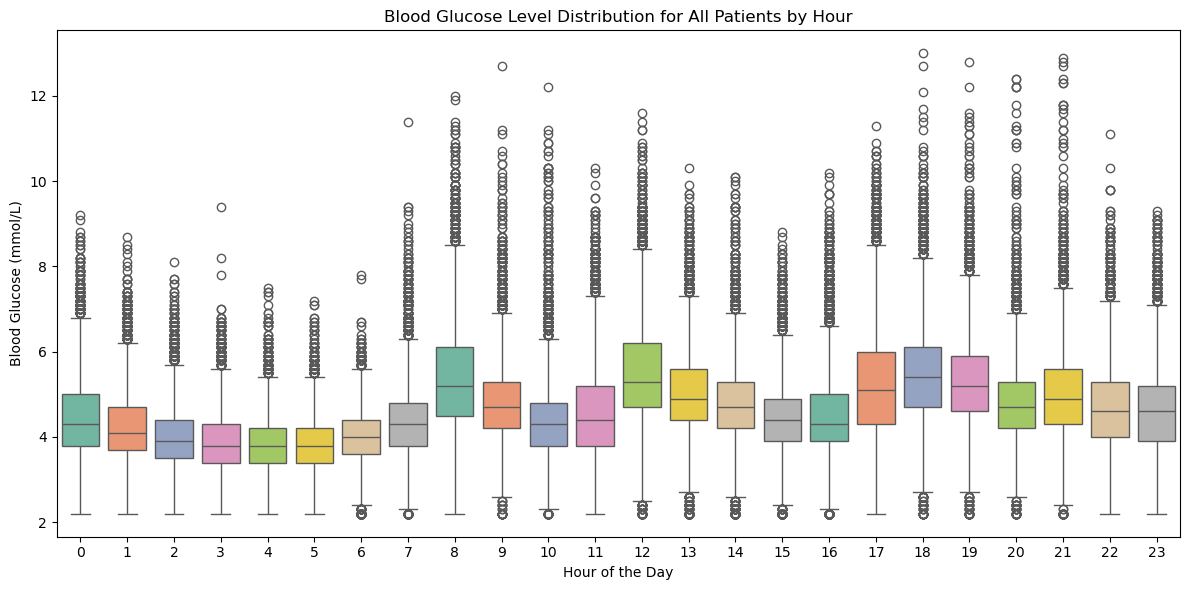

In [ ]:
all_data = []

for patient_id, patient_data in patients_data.items():
    patient_data['Timestamp'] = pd.to_datetime(patient_data['Timestamp'])  
    patient_data['Hour'] = patient_data['Timestamp'].dt.hour  # per hour
    patient_data['Patient_ID'] = patient_id
    all_data.append(patient_data)

df_all = pd.concat(all_data)

# boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='Hour', y='Glucose_History', data=df_all, palette='Set2')

plt.title('Blood Glucose Level Distribution for All Patients by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Blood Glucose (mmol/L)')
plt.tight_layout()
plt.show()

C:\Users\adayc\AppData\Local\Temp\ipykernel_22628\669414063.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Hour', y='Glucose_History', data=df_all, palette='Set2')


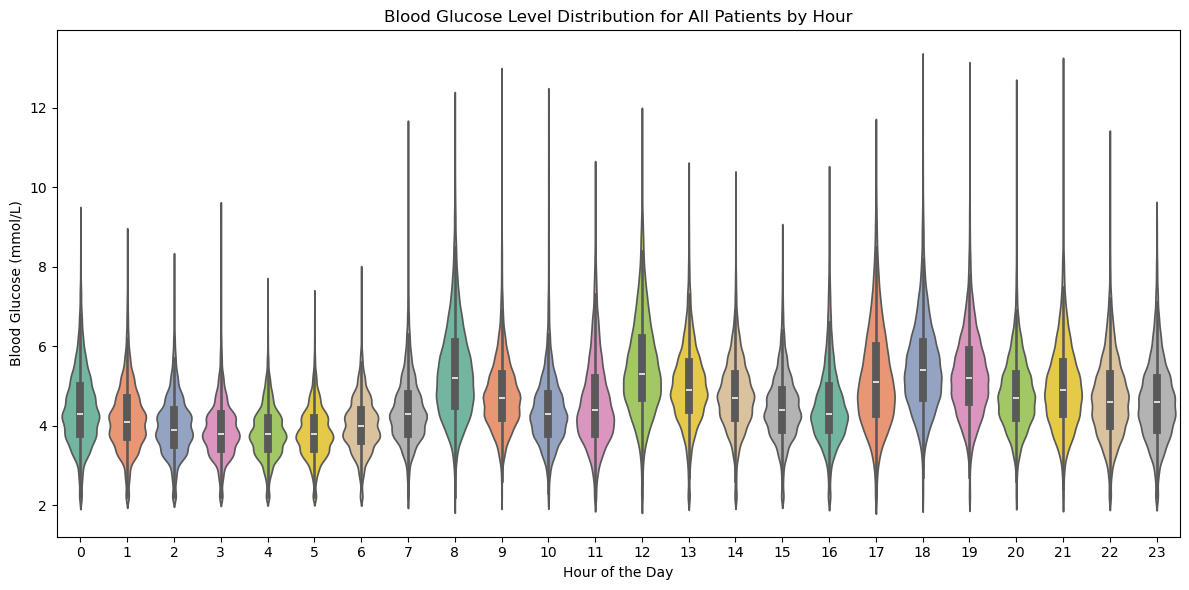

In [ ]:
# violinplot
plt.figure(figsize=(12, 6))
sns.violinplot(x='Hour', y='Glucose_History', data=df_all, palette='Set2')

plt.title('Blood Glucose Level Distribution for All Patients by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Blood Glucose (mmol/L)')
plt.tight_layout()
plt.show()